In [38]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# Pull 2025 year of Apple data
apple = yf.download("AAPL", start="2025-01-01", end="2026-01-01")

# Look at the first few rows
apple.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-01-02,242.525177,247.746654,240.506207,247.577564,55740700
2025-01-03,242.037827,242.853364,240.575812,242.037827,40244100
2025-01-06,243.668915,245.986258,241.878691,242.982661,45045600
2025-01-07,240.894089,244.215939,240.038760,241.659894,40856000
2025-01-08,241.381409,242.385931,238.745812,240.605648,37628900


# APPLE

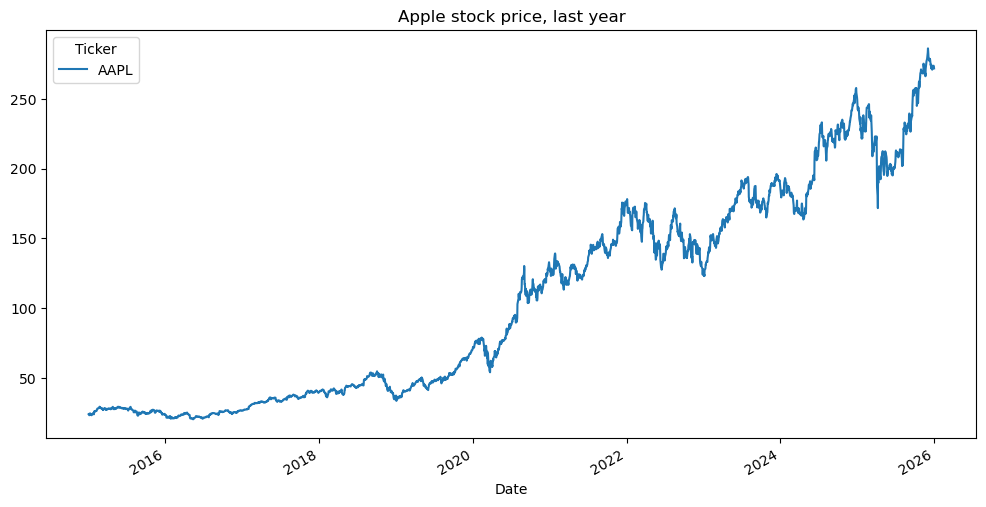

In [27]:
apple["Close"].plot(title="Apple stock price, last year", figsize=(12, 6))
plt.show()

# MAG 7

In [53]:
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA", "TSLA"]
data = yf.download(tickers , start="2025-01-01", end="2026-01-01")["Close"]
data.head()

[*********************100%***********************]  7 of 7 completed


Ticker,AAPL,AMZN,GOOGL,META,MSFT,NVDA,TSLA
Date,,,,,,,
2025-01-02,242.525162,220.220001,188.558258,596.845276,414.568604,138.264679,379.279999
2025-01-03,242.037811,224.190002,190.907410,602.213745,419.292908,144.422684,410.440002
2025-01-06,243.668900,227.610001,195.964020,627.681580,423.749817,149.381042,411.049988
2025-01-07,240.894058,222.110001,194.590393,615.420837,418.322296,140.094086,394.359985
2025-01-08,241.381409,222.130005,193.057465,608.279419,420.491272,140.064117,394.940002


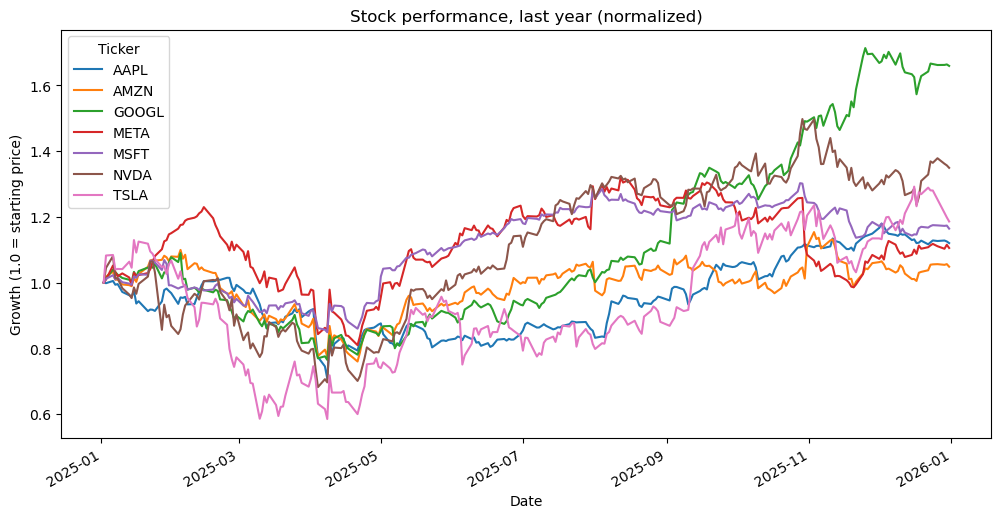

In [54]:
normalized = data / data.iloc[0]
normalized.plot(title="Stock performance, last year (normalized)", figsize=(12, 6))
plt.ylabel("Growth (1.0 = starting price)")
plt.show()

In [55]:
data.sort_values(by='Date', ascending=False)

Ticker,AAPL,AMZN,GOOGL,META,MSFT,NVDA,TSLA
Date,,,,,,,
2025-12-31,271.605835,230.820007,312.779816,659.525330,482.518677,186.489914,449.720001
2025-12-30,272.824707,232.529999,313.629242,665.380310,486.369904,187.529846,454.429993
2025-12-29,273.504089,232.070007,313.339417,658.126526,485.990753,188.209808,459.640015
2025-12-26,273.144409,232.520004,313.289459,662.722595,486.599365,190.519684,475.190002
2025-12-24,273.554016,232.380005,313.869049,666.978943,486.908630,188.599792,485.399994
...,...,...,...,...,...,...,...
2025-01-08,241.381409,222.130005,193.057465,608.279419,420.491272,140.064117,394.940002
2025-01-07,240.894058,222.110001,194.590393,615.420837,418.322296,140.094086,394.359985
2025-01-06,243.668900,227.610001,195.964020,627.681580,423.749817,149.381042,411.049988


# SP500

In [84]:
spy = yf.download("VOO", start="2025-01-01", end="2026-01-01")["Close"]
data["SP500"] = spy
data.tail()

[*********************100%***********************]  1 of 1 completed


Ticker,AAPL,AMZN,GOOGL,META,MSFT,NVDA,TSLA,SP500
Date,,,,,,,,
2025-12-24,273.554016,232.380005,313.869049,666.978943,486.908630,188.599792,485.399994,632.782593
2025-12-26,273.144409,232.520004,313.289459,662.722595,486.599365,190.519684,475.190002,632.842407
2025-12-29,273.504089,232.070007,313.339417,658.126526,485.990753,188.209808,459.640015,630.609436
2025-12-30,272.824707,232.529999,313.629242,665.380310,486.369904,187.529846,454.429993,629.732178
2025-12-31,271.605835,230.820007,312.779816,659.525330,482.518677,186.489914,449.720001,625.156677


In [85]:
returns = (data.iloc[-1] / data.iloc[0] - 1) * 100
returns = returns.round(2).astype(str) + "%"
returns.sort_values(ascending=False)

Ticker
GOOGL    65.88%
AMZN      4.81%
NVDA     34.88%
TSLA     18.57%
SP500    18.12%
MSFT     16.39%
AAPL     11.99%
META      10.5%
dtype: object

In [86]:
daily_returns = data.pct_change()
daily_returns.head()

Ticker,AAPL,AMZN,GOOGL,META,MSFT,NVDA,TSLA,SP500
Date,,,,,,,,
2025-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-03,-0.002009,0.018027,0.012458,0.008995,0.011396,0.044538,0.082156,0.012913
2025-01-06,0.006739,0.015255,0.026487,0.042290,0.010630,0.034332,0.001486,0.005823
2025-01-07,-0.011388,-0.024164,-0.007010,-0.019533,-0.012808,-0.062170,-0.040603,-0.011250
2025-01-08,0.002023,0.000090,-0.007878,-0.011604,0.005185,-0.000214,0.001471,0.001349


In [87]:
import numpy as np

annual_volatility = daily_returns.std() * np.sqrt(252) * 100
annual_volatility.sort_values(ascending=False).round(2)

Ticker
TSLA     63.31
NVDA     49.64
META     38.03
AMZN     34.49
AAPL     32.46
GOOGL    32.41
MSFT     24.30
SP500    18.57
dtype: float64

# Sharpe Ratio

In [88]:
returns_decimal = (data.iloc[-1] / data.iloc[0] - 1)  # not multiplied by 100 this time
sharpe = (returns_decimal / (daily_returns.std() * np.sqrt(252))).round(2)
sharpe.sort_values(ascending=False)

Ticker
GOOGL    2.03
SP500    0.98
NVDA     0.70
MSFT     0.67
AAPL     0.37
TSLA     0.29
META     0.28
AMZN     0.14
dtype: float64

# Max Drawdown

In [89]:
def max_drawdown(prices):
    running_max = prices.cummax()
    drawdown = (prices - running_max) / running_max
    return drawdown.min()

drawdowns = data.apply(max_drawdown) * 100
drawdowns = drawdowns.round(2).astype(str) + '%'
drawdowns.sort_values()

Ticker
SP500    -18.69%
MSFT     -20.56%
GOOGL    -29.81%
AAPL     -30.22%
AMZN     -30.88%
META     -34.15%
NVDA     -36.88%
TSLA     -48.19%
dtype: object

# Summary

In [90]:
summary = pd.DataFrame({
    "Total Return %": ((data.iloc[-1] / data.iloc[0] - 1) * 100).round(2).astype(str) + '%',
    "Annual Vol %": (daily_returns.std() * np.sqrt(252) * 100).round(2).astype(str) + '%',
    "Sharpe": (returns_decimal / (daily_returns.std() * np.sqrt(252))).round(2),
    "Max Drawdown %": (data.apply(max_drawdown) * 100).round(2).astype(str) + '%'
})

summary.sort_values("Sharpe", ascending=False)

,Total Return %,Annual Vol %,Sharpe,Max Drawdown %
Ticker,,,,
GOOGL,65.88%,32.41%,2.03,-29.81%
SP500,18.12%,18.57%,0.98,-18.69%
NVDA,34.88%,49.64%,0.70,-36.88%
MSFT,16.39%,24.3%,0.67,-20.56%
AAPL,11.99%,32.46%,0.37,-30.22%
TSLA,18.57%,63.31%,0.29,-48.19%
META,10.5%,38.03%,0.28,-34.15%
AMZN,4.81%,34.49%,0.14,-30.88%


# Equal-weighted Mag 7 portfolio

In [91]:
mag7 = ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA", "TSLA"]

# Daily returns of just the Mag 7 (drop SPY for this calc)
mag7_returns = daily_returns[mag7]

# Equal-weight portfolio: average the daily returns across all 7
portfolio_returns = mag7_returns.mean(axis=1)

# Compound them up to get the portfolio's price path (starting at 1.0)
portfolio_value = (1 + portfolio_returns).cumprod()
portfolio_value.iloc[0] = 1.0  # set day 1 to 1.0 (it's NaN otherwise)

portfolio_value.tail()

Date
2025-12-24    1.288439
2025-12-26    1.284645
2025-12-29    1.274828
2025-12-30    1.274332
2025-12-31    1.265747
dtype: float64

# Portfolio Summary`

In [93]:
port_total_return = (portfolio_value.iloc[-1] / portfolio_value.iloc[0] - 1) * 100
port_annual_vol = portfolio_returns.std() * np.sqrt(252) * 100
port_sharpe = (portfolio_value.iloc[-1] / portfolio_value.iloc[0] - 1) / (portfolio_returns.std() * np.sqrt(252))
port_dd = max_drawdown(portfolio_value) * 100

print(f"Mag 7 Equal-Weight Portfolio (2025)")
print(f"  Total Return:  {port_total_return:.2f}%")
print(f"  Annual Vol:    {port_annual_vol:.2f}%")
print(f"  Sharpe:        {port_sharpe:.2f}")
print(f"  Max Drawdown:  {port_dd:.2f}%")

Mag 7 Equal-Weight Portfolio (2025)
  Total Return:  26.57%
  Annual Vol:    30.51%
  Sharpe:        0.87
  Max Drawdown:  -28.05%


# SP500 vs MAG 7

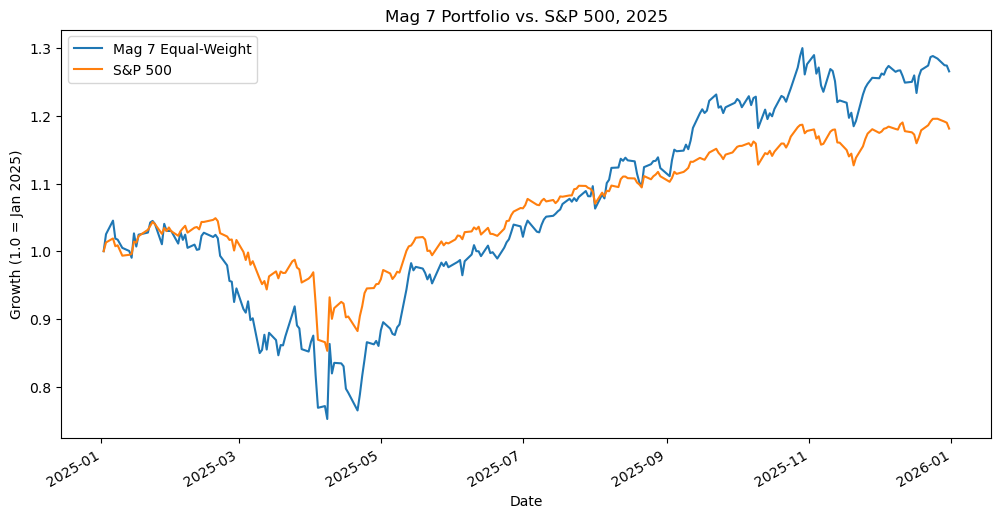

In [94]:
spy_normalized = data["SP500"] / data["SP500"].iloc[0]

plt.figure(figsize=(12, 6))
portfolio_value.plot(label="Mag 7 Equal-Weight")
spy_normalized.plot(label="S&P 500")
plt.title("Mag 7 Portfolio vs. S&P 500, 2025")
plt.ylabel("Growth (1.0 = Jan 2025)")
plt.legend()
plt.show()

# Correlation

In [17]:
correlation_matrix = daily_returns[mag7].corr()
correlation_matrix.round(2)

Ticker,AAPL,MSFT,GOOGL,AMZN,META,NVDA,TSLA
Ticker,,,,,,,
AAPL,1.00,0.49,0.50,0.57,0.49,0.44,0.53
MSFT,0.49,1.00,0.42,0.59,0.66,0.64,0.47
GOOGL,0.50,0.42,1.00,0.54,0.44,0.48,0.55
AMZN,0.57,0.59,0.54,1.00,0.66,0.57,0.53
META,0.49,0.66,0.44,0.66,1.00,0.54,0.52
NVDA,0.44,0.64,0.48,0.57,0.54,1.00,0.54
TSLA,0.53,0.47,0.55,0.53,0.52,0.54,1.00


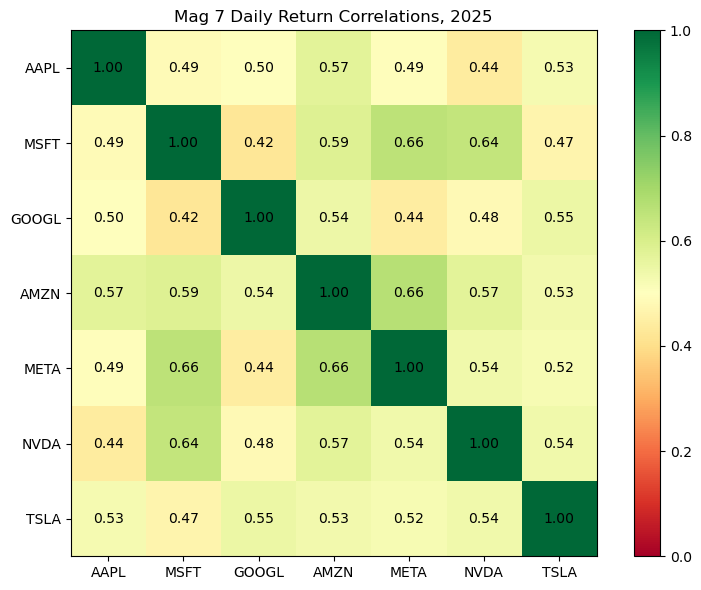

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(correlation_matrix, cmap="RdYlGn", vmin=0, vmax=1)

# Label the axes
ax.set_xticks(range(len(mag7)))
ax.set_yticks(range(len(mag7)))
ax.set_xticklabels(mag7)
ax.set_yticklabels(mag7)

# Write the actual numbers inside each cell
for i in range(len(mag7)):
    for j in range(len(mag7)):
        ax.text(j, i, f"{correlation_matrix.iloc[i, j]:.2f}",
                ha="center", va="center", color="black")

plt.colorbar(im)
plt.title("Mag 7 Daily Return Correlations, 2025")
plt.tight_layout()
plt.show()